# Waste Detection System

## Data Preprocessing

In [2]:
# imports
import cv2
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy

In [4]:
# create a TensorFlow image dataset from the directory
data_dir = 'C:\\Users\\mikol\\OneDrive\\Dokumenty\\dataset-resized'
data = tf.keras.utils.image_dataset_from_directory(data_dir)

Found 2390 files belonging to 5 classes.


In [6]:
class_names = data.class_names

# convert labels in the dataset to one-hot encoded labels
def one_hot_encode_label(label):
    return tf.one_hot(label, len(class_names))

data = data.map(lambda image, label: (image, one_hot_encode_label(label)))

In [7]:
data_iterator = data.as_numpy_iterator()
batch = data_iterator.next()

C:\Users\mikol\AppData\Local\Programs\Python\Python310\lib\site-packages\matplotlib\text.py:1279: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  if s != self._text:


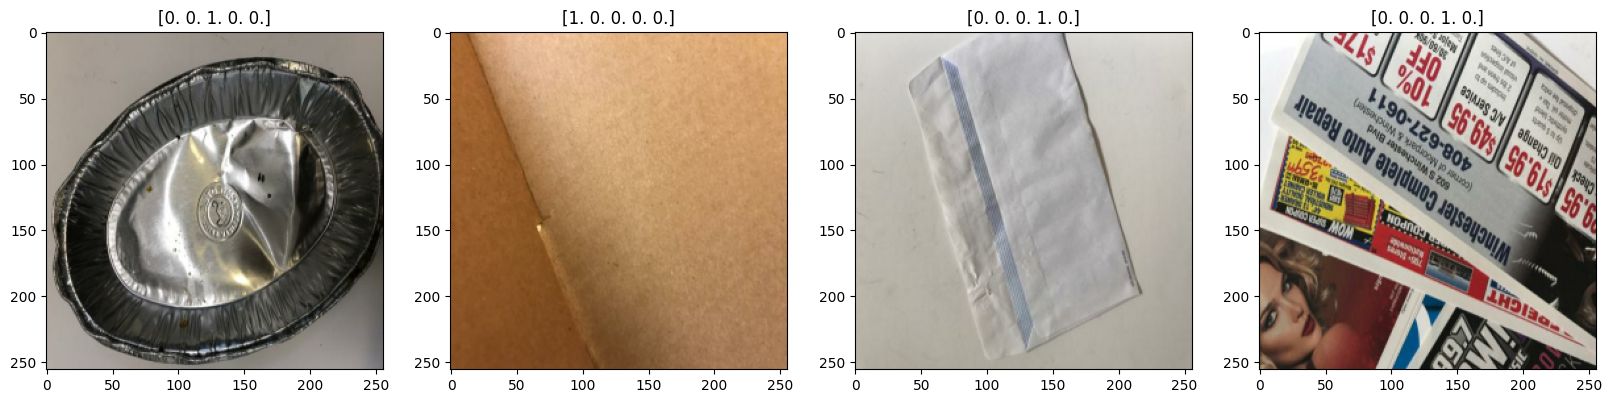

In [8]:
# create subplots
fig, ax = plt.subplots(ncols=4, figsize=(20,20))
for idx, img in enumerate(batch[0][:4]):
    ax[idx].imshow(img.astype(int))
    ax[idx].title.set_text(batch[1][idx])

In [10]:
data = data.map(lambda x,y: (x/255, y))

In [11]:

data.as_numpy_iterator().next()[0].max()

1.0

In [12]:
len(data)

75

In [41]:
train_size = 55
val_size = 15
test_size = 5

In [15]:
train = data.take(train_size)
val = data.skip(train_size).take(val_size)
test = data.skip(train_size+val_size).take(test_size)

## CNN Model

### Model Definition

In [18]:
# imports
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout
from keras.regularizers import l2

In [19]:
model = Sequential()
model.add(Conv2D(16, (3, 3), activation='relu', input_shape=(256, 256, 3), kernel_regularizer=l2(0.01)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))  
model.add(Conv2D(32, (3, 3), activation='relu', kernel_regularizer=l2(0.01)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))  
model.add(Conv2D(16, (3, 3), activation='relu', kernel_regularizer=l2(0.01)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))  
model.add(Flatten())
model.add(Dense(256, activation='relu', kernel_regularizer=l2(0.01)))
model.add(Dropout(0.5))  
model.add(Dense(5, activation='softmax'))


In [20]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 254, 254, 16)      448       
                                                                 
 max_pooling2d (MaxPooling2  (None, 127, 127, 16)      0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 127, 127, 16)      0         
                                                                 
 conv2d_1 (Conv2D)           (None, 125, 125, 32)      4640      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 62, 62, 32)        0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 62, 62, 32)        0

In [21]:
logdir='logs'

In [22]:
tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir=logdir)

### Model Training

In [23]:
# model training
hist = model.fit(train, epochs=40, validation_data=val, callbacks=[tensorboard_callback])

Epoch 1/40
55/55 [==============================] - 86s 2s/step - loss: 2.9647 - accuracy: 0.2449 - val_loss: 1.8148 - val_accuracy: 0.2646
Epoch 2/40
55/55 [==============================] - 77s 1s/step - loss: 1.6574 - accuracy: 0.3756 - val_loss: 1.5820 - val_accuracy: 0.4917
Epoch 3/40
55/55 [==============================] - 77s 1s/step - loss: 1.5468 - accuracy: 0.4108 - val_loss: 1.5001 - val_accuracy: 0.4479
Epoch 4/40
55/55 [==============================] - 78s 1s/step - loss: 1.4894 - accuracy: 0.4290 - val_loss: 1.4730 - val_accuracy: 0.4833
Epoch 5/40
55/55 [==============================] - 78s 1s/step - loss: 1.4905 - accuracy: 0.4420 - val_loss: 1.4780 - val_accuracy: 0.4792
Epoch 6/40
55/55 [==============================] - 78s 1s/step - loss: 1.4459 - accuracy: 0.4790 - val_loss: 1.3833 - val_accuracy: 0.5500
Epoch 7/40
55/55 [==============================] - 79s 1s/step - loss: 1.4480 - accuracy: 0.4665 - val_loss: 1.3732 - val_accuracy: 0.5417
Epoch 8/40
55/55 [==

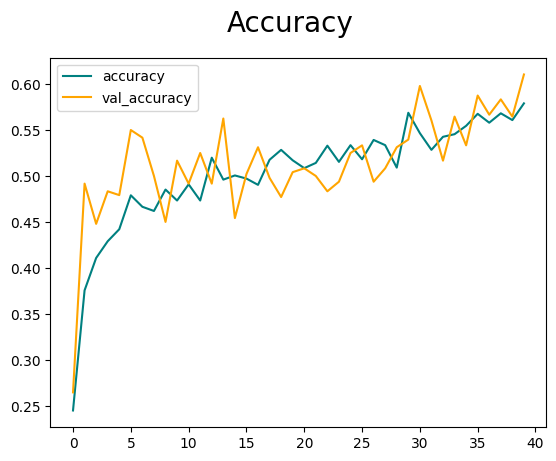

In [27]:
# accuracy and val_accuracy plot
fig = plt.figure()
plt.plot(hist.history['accuracy'], color='teal', label='accuracy')
plt.plot(hist.history['val_accuracy'], color='orange', label='val_accuracy')
fig.suptitle('Accuracy', fontsize=20)
plt.legend(loc="upper left")
plt.show()

### Model Testing

In [28]:
# model testing
from tensorflow.keras.metrics import Precision, Recall, CategoricalAccuracy

precision_metric = Precision()
recall_metric = Recall()
categorical_accuracy_metric = CategoricalAccuracy()

for batch in test.as_numpy_iterator():
    X, y = batch
    yhat = model.predict(X)

    # Update the metrics for each batch
    precision_metric.update_state(y, yhat)
    recall_metric.update_state(y, yhat)
    categorical_accuracy_metric.update_state(y, yhat)
precision_result = precision_metric.result()
recall_result = recall_metric.result()
categorical_accuracy_result = categorical_accuracy_metric.result()

print("Precision:", precision_result.numpy())
print("Recall:", recall_result.numpy())
print("Categorical Accuracy:", categorical_accuracy_result.numpy())


1/1 [==============================] - 0s 236ms/step
Precision: 0.7659575
Recall: 0.24
Categorical Accuracy: 0.53333336


1/1 [==============================] - 0s 64ms/step
The object is metal


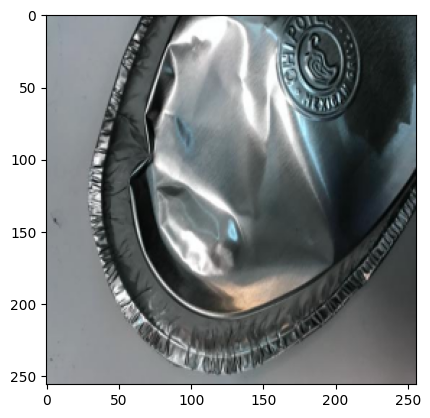

In [43]:
# model testing
img = cv2.imread('C:\\Users\\mikol\\OneDrive\\Dokumenty\\dataset-resized\\metal\\metal270.jpg')
resize = tf.image.resize(img, (256,256))
plt.imshow(resize.numpy().astype(int))
yhat = model.predict(np.expand_dims(resize/255, 0))
max_val_index = np.argmax(yhat[0])

if max_val_index == 0:
    print('The object is cardboard')
elif max_val_index == 1:
    print('The object is glass')
elif max_val_index == 2:
    print('The object is metal')
elif max_val_index == 3:
    print('The object is paper')
elif max_val_index == 4:
    print('The object is plastic')


In [31]:
import pickle

# save model
with open('waste_detection_cnn.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)



## Model Testing with Recorded Data

1/1 [==============================] - 0s 59ms/step



KeyboardInterrupt



Error in callback <function _draw_all_if_interactive at 0x0000027432E69120> (for post_execute):


KeyboardInterrupt: 

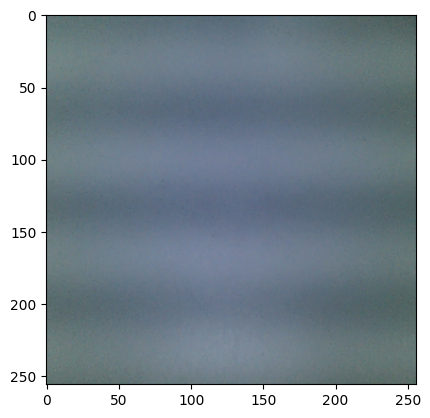

In [40]:
font = cv2.FONT_HERSHEY_SIMPLEX

# Define the codec and create a VideoWriter object
fourcc = cv2.VideoWriter_fourcc(*'XVID')  # You can choose a different codec
out = cv2.VideoWriter('output2.avi', fourcc, 20.0, (640, 480))  # Adjust the filename, codec, frame rate, and resolution as needed

cap = cv2.VideoCapture(0)

# Check if the camera opened successfully
if not cap.isOpened():
    print("Error: Could not open camera.")
else:
    while True:
        # Capture a frame from the camera
        ret, frame = cap.read()

        if not ret:
            print("Error: Could not read frame.")
            break

        # Display the frame in a window
        cv2.imshow('Live Video Feed', frame)

        # Write the frame to the output video file
        out.write(frame)

        resize = tf.image.resize(frame, (256, 256))
        plt.imshow(resize.numpy().astype(int))
        yhat = model.predict(np.expand_dims(resize / 255, 0))
        max_val_index = np.argmax(yhat[0])
        probabilityValue = np.amax(yhat[0])
        obj = 'Unidentified'

        if max_val_index == 0:
            obj = 'Cardboard'
        elif max_val_index == 1:
            obj = 'Glass'
        elif max_val_index == 2:
            obj = 'Metal'
        elif max_val_index == 3:
            obj = 'Paper'
        elif max_val_index == 4:
            obj = 'Plastic'

        cv2.putText(frame, obj, (120, 35), font, 0.75, (0, 0, 255), 2, cv2.LINE_AA)
        cv2.putText(frame, str(round(probabilityValue * 100, 2)) + "%", (180, 75), font, 0.75, (0, 0, 255), 2, cv2.LINE_AA)
        cv2.imshow("Result", frame)

        # Wait for a moment before displaying the next frame
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    # Release the VideoWriter and camera when done
    out.release()
    cap.release()
    cv2.destroyAllWindows()

